In [31]:
import torch
from torchvision.datasets.imagenette import Imagenette
import torchvision.transforms as transforms
from overcomplete.models import DinoV2
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from einops import rearrange
from overcomplete.sae import TopKSAE, train_sae
from overcomplete.sae.losses import top_k_auxiliary_loss
from torch.optim import Adam
from tqdm import tqdm
import numpy as np

In [32]:
dinoModel = DinoV2(device="cuda")

Using cache found in /home/st0pien/.cache/torch/hub/facebookresearch_dinov2_main


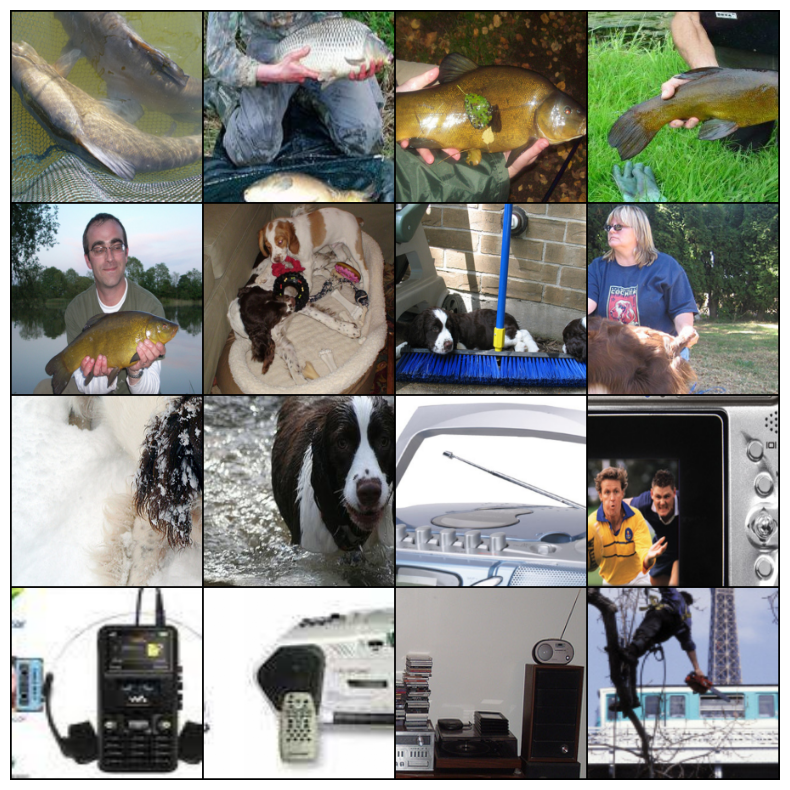

In [33]:
train_images = Imagenette(
    "./data",
    download=True,
    transform=transforms.Compose(
        [transforms.RandomResizedCrop(size=(224, 224)), transforms.ToTensor()]
    ),
)
train_loader = DataLoader(train_images, batch_size=128, num_workers=16, shuffle=True)


example_batch = [train_images[i * 200][0] for i in range(16)]
grid = make_grid(torch.stack(example_batch), 4)
grid = grid.permute(1, 2, 0)
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.imshow(grid)

In [34]:
Activations = []

for batch, _ in tqdm(train_loader):
    acts = dinoModel.forward_features(batch.to(dinoModel.device))
    Activations.append(acts)

Activations = torch.cat(Activations)
Activations = rearrange(Activations, 'n t d -> (n t) d')

100%|██████████| 74/74 [01:48<00:00,  1.46s/it]


In [35]:
from torch import ones, multinomial
from torch.distributions import MultivariateNormal


# class WeightedICALossFunction:
#     """
#     The weighted correlation loss (the independence loss).
#     """

#     def __init__(self, power, number_of_gausses, cuda, z_dim=None):
#         super(WeightedICALossFunction, self).__init__()
#         self.power = power
#         self.number_of_gausses = number_of_gausses
#         self.z_dim = z_dim
#         self.cuda = cuda
#         self.reduction_type = "mean"

#     def random_choice_full(self, input, n_samples):
#         if n_samples * self.number_of_gausses < input.shape[0]:
#             replacement = False
#         else:
#             replacement = True
#         idx = multinomial(
#             ones(input.shape[0]),
#             n_samples * self.number_of_gausses,
#             replacement=replacement,
#         )
#         sampled = input[idx].reshape(self.number_of_gausses, n_samples, -1)
#         return torch.mean(sampled, axis=1)

#     def loss(self, z, latent_normalization=True):
#         if latent_normalization:
#             x = (z - z.mean(axis=0)) / (z.std(axis=0) + 1e-8)
#         else:
#             x = z
#         dim = self.z_dim if self.z_dim is not None else x.shape[1]
#         scale = (1 / dim) ** self.power
#         sampled_points = self.random_choice_full(x, dim)

#         cov_mat = (scale * torch.eye(dim)).repeat(self.number_of_gausses, 1, 1)
#         if self.cuda:
#             cov_mat = cov_mat.cuda()

#         mvn = MultivariateNormal(loc=sampled_points, covariance_matrix=cov_mat)

#         weight_vector = torch.exp(mvn.log_prob(x.reshape(-1, 1, dim)))
#         sum_of_weights = torch.sum(weight_vector, axis=0)

#         weight_sum = torch.sum(
#             x * weight_vector.T.reshape(self.number_of_gausses, -1, 1), axis=1
#         )
#         weight_mean = weight_sum / (sum_of_weights.reshape(-1, 1) + 1e-8)

#         xm = x - weight_mean.reshape(self.number_of_gausses, 1, -1)
#         wxm = xm * weight_vector.T.reshape(self.number_of_gausses, -1, 1)

#         wcov = (wxm.permute(0, 2, 1).matmul(xm)) / (sum_of_weights.reshape(-1, 1, 1) + 1e-8)

#         diag = torch.diagonal(wcov**2, dim1=1, dim2=2)
#         diag_pow_plus = diag.reshape(diag.shape[0], diag.shape[1], -1) + diag.reshape(
#             diag.shape[0], -1, diag.shape[1]
#         )

#         tmp = 2 * wcov**2 / (diag_pow_plus + 1e-8)
#         triu = torch.triu(tmp, diagonal=1)
#         normalize = 2.0 / (dim * (dim - 1))
#         cost = torch.sum(normalize * triu) / self.number_of_gausses
#         return cost


class WeightedICALossFunction:
    """
    The weighted correlation loss (the independence loss).
    """
    def __init__(self, power, number_of_gausses, cuda, z_dim=None):
        super(WeightedICALossFunction, self).__init__()
        self.power = power
        self.number_of_gausses = number_of_gausses
        self.z_dim = z_dim
        self.cuda = cuda
        self.reduction_type = "mean"

    def random_choice_full(self, input, n_samples):
        if n_samples * self.number_of_gausses < input.shape[0]:
            replacement = False
        else:
            replacement = True
        idx = multinomial(ones(input.shape[0]), n_samples * self.number_of_gausses, replacement=replacement)
        sampled = input[idx].reshape(self.number_of_gausses, n_samples, -1)
        return torch.mean(sampled, axis=1)

    def loss(self, z, latent_normalization=True):
        if latent_normalization:
            x = (z - z.mean(axis=0)) / z.std(axis=0)
        else:
            x = z
        dim = self.z_dim if self.z_dim is not None else x.shape[1]
        scale = (1 / dim) ** self.power
        sampled_points = self.random_choice_full(x, dim)

        cov_mat = (scale * torch.eye(dim)).repeat(self.number_of_gausses, 1, 1)
        if self.cuda:
            cov_mat = cov_mat.cuda()

        mvn = MultivariateNormal(loc=sampled_points,
                                 covariance_matrix=cov_mat)

        weight_vector = torch.exp(mvn.log_prob(x.reshape(-1, 1, dim)))
        sum_of_weights = torch.sum(weight_vector, axis=0)

        weight_sum = torch.sum(x * weight_vector.T.reshape(self.number_of_gausses, -1, 1), axis=1)
        weight_mean = weight_sum / sum_of_weights.reshape(-1, 1)

        xm = x - weight_mean.reshape(self.number_of_gausses, 1, -1)
        wxm = xm * weight_vector.T.reshape(self.number_of_gausses, -1, 1)

        wcov = (wxm.permute(0, 2, 1).matmul(xm)) / sum_of_weights.reshape(-1, 1, 1)

        diag = torch.diagonal(wcov ** 2, dim1=1, dim2=2)
        diag_pow_plus = diag.reshape(diag.shape[0], diag.shape[1], -1) + diag.reshape(diag.shape[0], -1, diag.shape[1])

        tmp = (2 * wcov ** 2 / diag_pow_plus)
        triu = torch.triu(tmp, diagonal=1)
        normalize = 2.0 / (dim * (dim - 1))
        cost = torch.sum(normalize * triu) / self.number_of_gausses
        return cost

In [36]:
topk = 5

In [37]:
wica_loss = WeightedICALossFunction(1, topk, True)
wica_values = []

def combined_loss(x, x_hat, pre_codes, codes, dictionary, k=topk, wica_penalty=100):
    topk = torch.topk(codes, k=k).values
    # print(topk)
    with torch.no_grad():
        wica = wica_loss.loss(topk)
    mse_topk = top_k_auxiliary_loss(x, x_hat, pre_codes, codes, dictionary)
    wica_values.append(wica)
    # print(wica)

    return mse_topk + wica_penalty * wica

def mse(x, x_hat, pre_codes, codes, dictionary):
    mse = (x - x_hat).square().mean()
    return mse

def mse_with_wica_report(x, x_hat, pre_codes, codes, dictionary, k=topk):
    # print(topk)
    with torch.no_grad():
        wica = wica_loss.loss(codes)
    loss = mse(x, x_hat, pre_codes, codes, dictionary)
    wica_values.append(wica)
    # print(wica)

    return loss


def topk_with_wica_report(x, x_hat, pre_codes, codes, dictionary, k=topk):
    with torch.no_grad():
        wica = wica_loss.loss(codes)
    loss = top_k_auxiliary_loss(x, x_hat, pre_codes, codes, dictionary)
    wica_values.append(wica)

    return loss

In [38]:
dataloader = DataLoader(TensorDataset(Activations), batch_size=1024, shuffle=True)
sae = TopKSAE(384, nb_concepts=500, top_k=topk, device="cuda")
optimizer = Adam(sae.parameters(), lr=5e-4)

logs = train_sae(
    sae, dataloader, topk_with_wica_report, optimizer, nb_epochs=10, device="cuda"
)

ValueError: Expected parameter loc (Tensor of shape (5, 500)) of distribution MultivariateNormal(loc: torch.Size([5, 500]), covariance_matrix: torch.Size([5, 500, 500])) to satisfy the constraint IndependentConstraint(Real(), 1), but found invalid values:
tensor([[-0.0696, -0.0024,  0.0944,  ...,  0.0066, -0.0400, -0.0032],
        [ 0.0416, -0.0288,  0.0213,  ...,  0.0837, -0.0408, -0.0011],
        [-0.0892,  0.0076, -0.0436,  ..., -0.0333,  0.0680,  0.0014],
        [ 0.0017, -0.0014, -0.0038,  ..., -0.0522, -0.0115, -0.0329],
        [ 0.1141, -0.0486,  0.0193,  ...,  0.0094, -0.0408,  0.0169]],
       device='cuda:0')

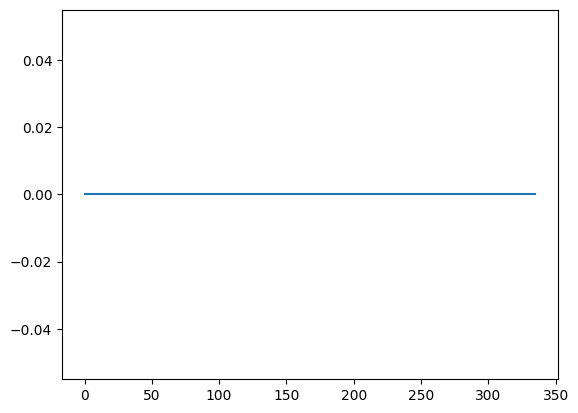

In [ ]:
a = [x.item() for x in wica_values]
size = 100
chunks = int(np.ceil(len(a) / size))
a = [np.mean(a[i * size:(i+1)*size]) for i in range(chunks)]
plt.plot(a)

In [ ]:
from overcomplete.visualization import overlay_top_heatmaps, evidence_top_images, contour_top_image

# great, now let inspect the results !
# first we reshape the code to see them patch-wise
# then we will use `overlay_top_heatmaps`
# a little function to show the top concepts

val_data = Imagenette(
    "./data",
    split="val",
    transform=transforms.Compose(
        [transforms.RandomResizedCrop(size=(224, 224)), transforms.ToTensor()]
    ),
)
val_loader = DataLoader(val_data, batch_size=256, shuffle=True)
images = next(iter(val_loader))[0].to('cuda')
val_activations = dinoModel.forward_features(images)
val_activations = rearrange(val_activations, 'n t d -> (n t) d')

sae = sae.eval()

with torch.no_grad():
    pre_codes, codes = sae.encode(val_activations)

codes = rearrange(codes, "(n w h) d -> n w h d", w=16, h=16)

for i in range(0, 50):
    print("Concept", i)
    overlay_top_heatmaps(images, codes, concept_id=i)
    plt.show()